## Modelagem dos dados

O MVP utiliza tabelas Delta relacionadas por identificadores, como
paciente_id e cnes.

O processamento é organizado em camadas lógicas: Bronze, com os dados
recebidos dos arquivos Parquet; Silver, com os dados tratados utilizados
nas análises; e Gold, com resultados analíticos agregados.

A implementação prioriza a base de consultas. As demais tabelas carregadas
que não receberam tratamento completo permanecem na camada de entrada.

### Principais tabelas utilizadas

| Tabela | O que representa | Identificador ou relacionamento |
|---|---|---|
| consultas_ubs | Registros de consultas recebidos dos arquivos de origem | consulta_id, com unicidade e preenchimento verificados na base |
| consultas_tratadas | Consultas com dt_consulta convertida para DATE | consulta_id; relaciona-se com pacientes por paciente_id |
| exp_paciente | Cadastro consolidado utilizado para obter uma faixa etária por paciente | paciente_id |
| cadastro_pacientes_ubs | Registros cadastrais de pacientes vinculados às unidades | paciente_id e cnes, utilizados nos relacionamentos |
| acompanhamento_diab_ubs | Registros do acompanhamento de diabetes nas extrações | paciente_id; pode aparecer em várias linhas |
| acompanhamento_hiper_ubs | Registros do acompanhamento de hipertensão nas extrações | paciente_id; pode aparecer em várias linhas |
| pacientes_grupos | Classificação em somente diabetes, somente hipertensão ou ambos os planos | paciente_id |

### Relacionamentos e cuidados

Um paciente pode possuir várias consultas. O relacionamento entre
consultas_tratadas e exp_paciente utiliza paciente_id.

CNES identifica a unidade de saúde. Os identificadores são mantidos como
STRING, pois representam códigos e não valores destinados a cálculos.

As tabelas de acompanhamento podem conter várias linhas do mesmo paciente.
Por isso, a classificação dos grupos utiliza pacientes distintos,
evitando contar cada linha de acompanhamento como uma pessoa ou consulta.

A classificação em grupos considera a presença nos planos em qualquer
competência carregada. Ela não comprova participação simultânea nos dois
planos em uma mesma data.

### Organização do processamento

Arquivos Parquet → tabelas Delta de entrada → tratamento e validações
→ tabelas derivadas → consultas analíticas.

As tabelas de entrada são preservadas. O tratamento de dt_consulta é
armazenado em consultas_tratadas, e a classificação dos pacientes é
armazenada em pacientes_grupos.

Essa etapa lê o arquivo cadastro_pacientes_ubs.parquet que foi armazenado no volume entrada. 
Exibe os nomes e tipos das colunas e conta os registros, sem apresentar informações dos pacientes.

In [0]:
caminho = "/Volumes/workspace/vitacare_mvp/entrada"

cadastro = spark.read.parquet(
    f"{caminho}/cadastro_pacientes_ubs.parquet"
)

cadastro.printSchema()

print(f"Quantidade de registros: {cadastro.count():,}")


root
 |-- paciente_id: string (nullable = true)
 |-- cnes: string (nullable = true)
 |-- estab_saude: string (nullable = true)
 |-- ine: string (nullable = true)
 |-- bairro: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- faixa_etaria: string (nullable = true)
 |-- auxilio_brasil: string (nullable = true)
 |-- primeira_competencia: string (nullable = true)
 |-- ultima_competencia: string (nullable = true)
 |-- qtd_competencias: string (nullable = true)

Quantidade de registros: 261,030


Nesta etapa  grava os dados de cadastro no workspace, permitindo consultas com SQL

In [0]:
%sql
create table if not exists workspace.vitacare_mvp.cadastro_pacientes_ubs
using delta as select * from parquet.`/Volumes/workspace/vitacare_mvp/entrada/cadastro_pacientes_ubs.parquet`;

num_affected_rows,num_inserted_rows


Contagem dos registro da tabela de cadastro 

In [0]:
%sql
SELECT COUNT(*) AS total_registros, COUNT(DISTINCT paciente_id) as pacientes_distintos
FROM workspace.vitacare_mvp.cadastro_pacientes_ubs;

total_registros,pacientes_distintos
261030,236912


Criação das outra tabelas a partir dos arquivos parquet. 

In [0]:
%python
caminho = "/Volumes/workspace/vitacare_mvp/entrada"

nomes = [
    "acompanhamento_diab_ubs",
    "acompanhamento_hiper_ubs",
    "atendimentos_cid_ubs",
    "consultas_ubs",
    "exames_ubs",
    "exp_cadastro_presenca",
    "exp_paciente",
    "exp_profissional",
    "ficha_a_ubs",
]

resultado = []

for nome in nomes:
    arquivo = f"{caminho}/{nome}.parquet"
    tabela = f"workspace.vitacare_mvp.{nome}"

    spark.sql(f"""
        CREATE TABLE IF NOT EXISTS {tabela}
        USING DELTA
        AS SELECT * FROM parquet.`{arquivo}`
    """)

    linhas_arquivo = spark.read.parquet(arquivo).count()
    linhas_tabela = spark.table(tabela).count()

    resultado.append((
        nome,
        linhas_arquivo,
        linhas_tabela,
        "OK" if linhas_arquivo == linhas_tabela else "DIVERGÊNCIA"
    ))

display(spark.createDataFrame(
    resultado,
    ["tabela", "registros_arquivo", "registros_tabela", "conferencia"]
))

tabela,registros_arquivo,registros_tabela,conferencia
acompanhamento_diab_ubs,70896,70896,OK
acompanhamento_hiper_ubs,182955,182955,OK
atendimentos_cid_ubs,22809,22809,OK
consultas_ubs,312339,312339,OK
exames_ubs,654224,654224,OK
exp_cadastro_presenca,1244746,1244746,OK
exp_paciente,236912,236912,OK
exp_profissional,893,893,OK
ficha_a_ubs,729696,729696,OK


Revisão dos formatos de hora e competência

Essas consultas verificam os valores armazenados em hora_consulta e competencia_extracao. O objetivo é definir o tratamento e documentar os formatos no catálogo. A competência representa o mês da extração, não necessariamente o mês do atendimento.

In [0]:
%sql
SELECT DISTINCT hora_consulta FROM workspace.vitacare_mvp.consultas_ubs
    ORDER BY hora_consulta LIMIT 20;

hora_consulta
00:00
00:30
03:00
05:50
05:52
06:00
06:01
06:02
06:03
06:04


In [0]:
%sql
SELECT competencia_extracao, COUNT(*) AS registros FROM workspace.vitacare_mvp.consultas_ubs
    GROUP BY competencia_extracao
    ORDER BY competencia_extracao;

competencia_extracao,registros
2025-09,62008
2025-10,63122
2025-11,74725
2025-12,59633
2026-01,52851


**Validação do formato dos horários**

A consulta a seguir conta horários preenchidos que não seguem o padrão HH:mm, com horas entre 00 e 23 e minutos entre 00 e 59. Valores ausentes serão contados separadamente. A validação para verificar o formato, não é referente ao horário de atendimento real.

In [0]:
%sql
SELECT COUNT(*) AS horarios_formato_invalido FROM workspace.vitacare_mvp.consultas_ubs
    WHERE hora_consulta IS NOT NULL AND TRIM(hora_consulta) <> '' AND NOT (TRIM(hora_consulta) RLIKE '^([01][0-9]|2[0-3]):[0-5][0-9]$');

horarios_formato_invalido
0


Verificando ausencias de horários.

In [0]:
%sql
SELECT COUNT(*) AS horarios_ausentes FROM workspace.vitacare_mvp.consultas_ubs
    WHERE hora_consulta IS NULL OR TRIM(hora_consulta) = '';

horarios_ausentes
0


**Resultado da validação dos horários**

Não foram encontrados horários ausentes nem valores fora do padrão HH:mm,
considerando a remoção de espaços nas extremidades. Os horários preenchidos
estão entre 00:00 e 23:59.

A coluna hora_consulta será mantida como STRING no formato HH:mm.
Esta verificação avalia o preenchimento e o formato.

**Validação da competência de extração**

A competência identifica o mês da extração dos dados, que pode ser diferente
do mês da consulta. Primeiro verificamos valores ausentes, considerando
nulos, vazios ou contendo apenas espaços.

In [0]:
%sql
SELECT COUNT(*) AS competencias_ausentes FROM workspace.vitacare_mvp.consultas_ubs
    WHERE competencia_extracao IS NULL OR TRIM(competencia_extracao) = '';

competencias_ausentes
0


**Conferência dos valores de competência**

Esta consulta apresenta todos os valores de competência e suas quantidades de registros. Os colchetes ajudam a identificar espaços nas extremidades. Como existem poucas competências, podemos conferir diretamente se seguem o padrão AAAA-MM e se os meses estão entre 01 e 12.

In [0]:
%sql
SELECT CONCAT('[', competencia_extracao, ']') AS competencia, LENGTH(competencia_extracao) AS quantidade_caracteres, COUNT(*) AS registros FROM workspace.vitacare_mvp.consultas_ubs
    GROUP BY competencia_extracao
    ORDER BY competencia_extracao;

competencia,quantidade_caracteres,registros
[2025-09],7,62008
[2025-10],7,63122
[2025-11],7,74725
[2025-12],7,59633
[2026-01],7,52851


**Resultado da validação da competência**

Não foram encontradas competências ausentes. Os valores existentes seguem o padrão AAAA-MM, sem espaços nas extremidades, abrangendo setembro de 2025 a janeiro de 2026.

A coluna competencia_extracao será mantida como STRING, pois representaano e mês, sem informação de dia.

**Regra de extração e validação temporal**

Conforme o processo de origem, a extração é realizada no mês seguinte ao mês de referência dos atendimentos.

O cruzamento confirmou essa relação em todos os 312.339 registros analisados: as consultas de agosto a dezembro de 2025 estão associadas às extrações de setembro de 2025 a janeiro de 2026, respectivamente.

Nas análises de atendimento, será utilizada dt_consulta. A coluna competencia_extracao será preservada para identificar o mês da extração e apoiar a rastreabilidade dos dados.

** Verificação do identificador das consultas**

Esta consulta compara o total de registros com a quantidade de identificadores preenchidos e distintos. Valores nulos, vazios ou contendo apenas espaços são considerados ausentes.

O objetivo é avaliar se consulta_id pode identificar registro únicos. Caso existam repetições, elas serão analisados antes de qualquer exclusão de dados.

In [0]:
%sql
SELECT COUNT(*) AS total_registros, COUNT(NULLIF(TRIM(consulta_id), '')) AS ids_preenchidos, COUNT(DISTINCT NULLIF(TRIM(consulta_id), '')) AS ids_distintos FROM workspace.vitacare_mvp.consultas_ubs;

total_registros,ids_preenchidos,ids_distintos
312339,312339,312339


**Resultado da validação do identificador das consultas**

Os 312.339 registros possuem consulta_id preenchido e distinto.

A coluna é candidata a chave da tabela de consultas e será mantida como STRING, pois representa um identificador, sem finalidade de cálculo.

Não foram encontrados identificadores de consulta repetidos ou ausentes, essa verificação será repetida nas próximas cargas.

In [0]:
%sql
SELECT COUNT(*) AS total_registros, COUNT(*) - COUNT(NULLIF(TRIM(paciente_id), '')) AS pacientes_ausentes, 
    COUNT(*) - COUNT(NULLIF(TRIM(cnes), '')) AS unidades_ausentes,
    COUNT(*) - COUNT(NULLIF(TRIM(profissional_id), '')) AS profissionais_ausentes
    FROM workspace.vitacare_mvp.consultas_ubs;

total_registros,pacientes_ausentes,unidades_ausentes,profissionais_ausentes
312339,0,0,459


**Resultado do preenchimento dos identificadores**

Todos os 312.339 registros possuem paciente_id e cnes preenchidos. Foram encontrados 459 registros sem profissional_id, considerando valores nulos, vazios ou apenas espaços.

Esses registros serão preservados nas análises de consultas. Nas análises por profissional, serão apresentados como “Não informado”.

Esta verificação avalia o preenchimento dos campos. A existência dos identificadores nas tabelas de referência é verificada separadamente.

**Distribuição das ausências de profissional por unidade**

Esta consulta apresenta as unidades com registros de consultas sem identificação do profissional. O resultado orientará a investigação da origem dessas ausências, sem excluir registros ou atribuir profissionais por suposição.

In [0]:
%sql
SELECT cnes, unidade, COUNT(*) AS consultas_sem_profissional FROM workspace.vitacare_mvp.consultas_ubs
    WHERE profissional_id IS NULL   OR TRIM(profissional_id) = ''
    GROUP BY cnes, unidade
    ORDER BY consultas_sem_profissional DESC;

cnes,unidade,consultas_sem_profissional
2266806,UNIDADE DE SAUDE DA FAMILIA PONTA GROSSA,169
2266784,UNIDADE DE SAUDE DA FAMILIA JARDIM ATLANTICO,91
5998107,USF BARROCO,45
2266822,UNIDADE DE SAUDE DA FAMILIA RECANTO,36
2696797,UNIDADE DE SAUDE DA FAMILIA SANTA PAULA,36
2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,33
4653653,USF MILTON DOS SANTOS ITAOCAIA,25
2266725,UNIDADE DE SAUDE DA FAMILIA PONTA NEGRA,12
6028977,UNIDADE DE SAUDE DA FAMILIA SAO JOSE I,5
2696789,UNIDADE DE SAUDE DA FAMILIA MUMBUCA,4


consulta para mostrar a estrutura sem exibir os dados dos pacientes

In [0]:
%sql
SELECT table_name AS tabela, column_name AS coluna, data_type AS tipo FROM workspace.information_schema.columns
    WHERE table_schema = 'vitacare_mvp'
    ORDER BY table_name, ordinal_position;

tabela,coluna,tipo
acompanhamento_diab_ubs,acomp_id,STRING
acompanhamento_diab_ubs,paciente_id,STRING
acompanhamento_diab_ubs,cnes,STRING
acompanhamento_diab_ubs,unidade,STRING
acompanhamento_diab_ubs,area_familia,STRING
acompanhamento_diab_ubs,microarea_familia,STRING
acompanhamento_diab_ubs,ta_min_2,STRING
acompanhamento_diab_ubs,ta_max_2,STRING
acompanhamento_diab_ubs,ta_data_2,STRING
acompanhamento_diab_ubs,hba1c,STRING


Verificar registros que estão sem identificação, do paciente , codigo da unidade, bairro ou faixa etária. Consider ausentes os valores nulos, vazios ou contendo apenas espaços. 

In [0]:
%sql
SELECT COUNT(*) AS total_registros
FROM workspace.vitacare_mvp.cadastro_pacientes_ubs;


total_registros
261030


In [0]:
%sql
SELECT COUNT(*) AS sem_paciente_id
FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
WHERE paciente_id IS NULL OR TRIM(paciente_id) = '';

sem_paciente_id
0


In [0]:
%sql
SELECT COUNT(*) AS sem_codigo_unidade
FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
WHERE cnes IS NULL OR TRIM(cnes) = '';

sem_codigo_unidade
0


In [0]:
%sql
SELECT COUNT(*) AS sem_bairro
FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
WHERE bairro IS NULL OR TRIM(bairro) = '';

sem_bairro
2026


In [0]:
%sql
SELECT COUNT(*) AS sem_faixa_etaria FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
 WHERE faixa_etaria IS NULL OR TRIM(faixa_etaria) = '';

sem_faixa_etaria
1


Dos 261.030 registros de cadastro, nenhum apresentou ausência de paciente_id ou CNES. Foram encontrados 2.026 registros sem bairro e um sem faixa etária. As contagens consideram valores nulos, vazios ou contendo apenas espaços. Os registros serão preservados, e as ausências serão explicitadas nas análises. Esses números representam registros, não pacientes distintos.

Consulta a lista de faixa etária e a quantidade de registro em cada uma, para verificar a padronização dos valores. As contagens representam registros de cadastros e podem incluir o mesmo paciente em mais de uma unidade.


In [0]:
%sql
SELECT faixa_etaria, COUNT(*) as quantidade_registros FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
GROUP BY faixa_etaria
ORDER BY faixa_etaria;

faixa_etaria,quantidade_registros
null,1
0-9,27299
10-19,33263
20-29,33260
30-39,32691
40-49,37200
50-59,33677
60-69,32381
70-79,20896
80-89,8011


A coluna faixa etária apresentou dez categorias e um registro nulo. Confirmando a padronização dos rótulos, mas não valida os cálculos da idade e nem a data de referencia utilizada

abaixo segue a consulta para contar quantos códigos de paciente estão associados a mais de uma faixa etária preenchida, de forma a avaliar se é possível atribuir uma única faixa a cada paciente.

In [0]:
%sql
SELECT COUNT(*) AS pacientes_com_faixas_diferentes FROM (
    SELECT paciente_id FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
        WHERE faixa_etaria IS NOT NULL AND TRIM(faixa_etaria) <> ''
        GROUP BY paciente_id HAVING COUNT(DISTINCT faixa_etaria) > 1
    ) AS verificacao;

pacientes_com_faixas_diferentes
1130


verificação de faixas diferentes após remoção de espaços. Verifica quantos pacientes possuem mais de uma faixa etária, desconsiderando espaços no início e no fim dos valores. O objetivo é distinguir diferenças de formatação de diferenças entre categorias.

In [0]:
%sql
SELECT COUNT(*) AS pacientes_com_faixas_diferentes FROM (
    SELECT paciente_id FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
        WHERE faixa_etaria IS NOT NULL AND TRIM(faixa_etaria) <> ''
        GROUP BY paciente_id HAVING COUNT(DISTINCT TRIM(faixa_etaria)) > 1
) AS verificacao;

pacientes_com_faixas_diferentes
1130


O resultado se manteve nos 1130, então vamos identificar os pacientes com faixas diferentes. 


In [0]:
%sql
SELECT TRIM(faixa_etaria) AS faixa_etaria, COUNT(DISTINCT paciente_id) AS quantidade_pacientes FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
  WHERE faixa_etaria IS NOT NULL AND TRIM(faixa_etaria) <> '' AND paciente_id IN (
      SELECT paciente_id FROM workspace.vitacare_mvp.cadastro_pacientes_ubs
        WHERE faixa_etaria IS NOT NULL AND TRIM(faixa_etaria) <> ''
        GROUP BY paciente_id
        HAVING COUNT(DISTINCT TRIM(faixa_etaria)) > 1
  )
GROUP BY TRIM(faixa_etaria)
ORDER BY faixa_etaria;

faixa_etaria,quantidade_pacientes
0-9,184
10-19,260
20-29,282
30-39,284
40-49,308
50-59,325
60-69,286
70-79,240
80-89,72
90+,22


In [0]:
%sql
SELECT TRIM(a.faixa_etaria) AS faixa_1, TRIM(b.faixa_etaria) AS faixa_2, COUNT(DISTINCT a.paciente_id) AS quantidade_pacientes FROM workspace.vitacare_mvp.cadastro_pacientes_ubs AS a
INNER JOIN workspace.vitacare_mvp.cadastro_pacientes_ubs AS b
    ON a.paciente_id = b.paciente_id
    WHERE TRIM(a.faixa_etaria) <> '' AND TRIM(b.faixa_etaria) <> '' AND TRIM(a.faixa_etaria) < TRIM(b.faixa_etaria)
    GROUP BY TRIM(a.faixa_etaria),TRIM(b.faixa_etaria)
    ORDER BY quantidade_pacientes DESC;

faixa_1,faixa_2,quantidade_pacientes
50-59,60-69,66
20-29,30-39,56
10-19,20-29,56
40-49,50-59,56
20-29,50-59,50
30-39,40-49,49
30-39,50-59,49
40-49,60-69,48
60-69,70-79,47
0-9,10-19,45


A encontrei divergência em pacientes associado a diferentes faixa etárias, o que não é compativel com o envelhecimento durante o período analisado. A causa permance em analise no processamento local. os registro preservados.

O cálculo da faixa etária e por vinbulo do paciente-unidade, usando a data de nascimento de origem e a última competência. Pode ocorrer diferenças entre faixas vizinhas , entretando foram identificados faixas distantes para o mesmo código,

Verificação do arquivo atualizado de pacientes
Esta etapa lê o novo arquivo exp_paciente.parquet, apresenta sua estrutura e compara o total de registros com a quantidade de códigos distintos de pacientes. A tabela existente ainda não é alterada.

In [0]:
%python
pacientes_novos = spark.read.parquet("/Volumes/workspace/vitacare_mvp/entrada/exp_paciente.parquet")
pacientes_novos.printSchema()

root
 |-- paciente_id: string (nullable = true)
 |-- regra_origem: string (nullable = true)
 |-- qtd_unidades: string (nullable = true)
 |-- primeira_competencia: string (nullable = true)
 |-- ultima_competencia: string (nullable = true)
 |-- faixa_etaria: string (nullable = true)



In [0]:
print("Total de registros:", pacientes_novos.count())
print("Códigos distintos:", pacientes_novos.select("paciente_id").distinct().count())

Total de registros: 236912
Códigos distintos: 236912


Atualização da tabela de pacientes
Esta etapa substitui o conteúdo e a estrutura da tabela exp_paciente pelos dados do arquivo atualizado. A nova versão inclui a faixa etária definida no processamento local para cada paciente.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.exp_paciente USING DELTA AS
SELECT * FROM parquet.`/Volumes/workspace/vitacare_mvp/entrada/exp_paciente.parquet`;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT faixa_etaria,COUNT(*) AS quantidade_pacientes FROM workspace.vitacare_mvp.exp_paciente
    GROUP BY faixa_etaria
    ORDER BY faixa_etaria;

faixa_etaria,quantidade_pacientes
0-9,24662
10-19,29818
20-29,29380
30-39,29082
40-49,33678
50-59,30843
60-69,30132
70-79,19524
80-89,7568
90+,2225



Resultado da distribuição etária

A tabela exp_paciente apresenta 236.912 pacientes distribuídos em dez faixas etárias, sem valores nulos no agrupamento. A faixa de 40–49 anos possui a maior quantidade, com 33.678 pacientes. A classificação segue a regra de referência definida no processamento local. Para análises por paciente, será utilizada essa tabela; cadastro_pacientes_ubs permanece representando os vínculos entre pacientes e unidades.

Verificação da ligação entre consultas e pacientes
Esta consulta conta os registros de consultas cujo paciente_id não encontra correspondência em exp_paciente. O resultado ajuda a identificar atendimentos que ficariam sem informações cadastrais em um cruzamento entre as tabelas.

In [0]:
%sql
SELECT COUNT(*) AS consultas_sem_correspondencia FROM workspace.vitacare_mvp.consultas_ubs AS c
LEFT JOIN workspace.vitacare_mvp.exp_paciente AS p
    ON c.paciente_id = p.paciente_id
    WHERE p.paciente_id IS NULL;

consultas_sem_correspondencia
0


Resultado da verificação de ligação

Não foram encontrados registros de consultas sem correspondência em exp_paciente. todas as consultas podem ser relacionadas ao cadastro de pacientes utilizando o campo paciente_id




A consulta abaixo relaciona consultas_ubs a exp_paciente e apresenta, por faixa etária, o total de registros de consultas e a quantidade de pacientes atendido distintos.

In [0]:
%sql
SELECT p.faixa_etaria, COUNT(*) AS registros_consultas, COUNT(DISTINCT c.paciente_id) AS pacientes_atendidos 
FROM workspace.vitacare_mvp.consultas_ubs AS c
    INNER JOIN workspace.vitacare_mvp.exp_paciente AS p
        ON c.paciente_id = p.paciente_id
    GROUP BY p.faixa_etaria
    ORDER BY p.faixa_etaria;

faixa_etaria,registros_consultas,pacientes_atendidos
0-9,34375,12268
10-19,27871,10457
20-29,31208,8715
30-39,33297,9119
40-49,41024,11367
50-59,46001,12082
60-69,52014,13198
70-79,33768,8439
80-89,10807,2760
90+,1974,587


A faixa de 60–69 anos apresentou o maior volume de registros de consultas (52.014) e de pacientes distintos atendidos (13.198). Os resultados consideram todos os registros carregados e a faixa etária de referência definida em exp_paciente. Não representam, necessariamente, a idade na data do atendimento nem indicam maior risco de adoecimento.

**Média de registros de consultas por paciente atendido**

Esta consulta divide a quantidade de registros de consultas pelo número de pacientes distintos atendidos em cada faixa etária.
A média considera somente os paciente com consutas na base.



In [0]:
%sql
select p.faixa_etaria, COUNT(*) AS registros_consultas, COUNT(DISTINCT c.paciente_id) as paciente_atendidiso,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT c.paciente_id), 2) as media_consultas_por_paciente
from workspace.vitacare_mvp.consultas_ubs c
inner join workspace.vitacare_mvp.exp_paciente p
    on c.paciente_id = p.paciente_id
group by p.faixa_etaria
order by p.faixa_etaria

faixa_etaria,registros_consultas,paciente_atendidiso,media_consultas_por_paciente
0-9,34375,12268,2.80
10-19,27871,10457,2.67
20-29,31208,8715,3.58
30-39,33297,9119,3.65
40-49,41024,11367,3.61
50-59,46001,12082,3.81
60-69,52014,13198,3.94
70-79,33768,8439,4.00
80-89,10807,2760,3.92
90+,1974,587,3.36


A faixa de 70–79 anos apresentou a maior média de registros de consultas por paciente atendido (4,00), enquanto a faixa de 60–69 anos concentrou o maior volume absoluto (52.014). A menor média ocorreu entre 10–19 anos (2,67). O indicador considera somente pacientes com consultas na base e todo o período carregado; não é uma média mensal. As faixas seguem a classificação de referência de exp_paciente.

In [0]:
%sql
DESCRIBE TABLE workspace.vitacare_mvp.consultas_ubs;

col_name,data_type,comment
consulta_id,string,null
paciente_id,string,null
profissional_id,string,null
cnes,string,null
unidade,string,null
ine,string,null
ap,string,null
dt_consulta,string,null
hora_consulta,string,null
cbo_presc,string,null


**Conversão da data de consulta**
Verificar os exemplos dos valores de dt_consulta para identificar o formato de origem. A conversão será testada em todos os registros.

In [0]:
%sql
select distinct dt_consulta from workspace.vitacare_mvp.consultas_ubs 
    where dt_consulta is not null and dt_consulta <> ''
    order by dt_consulta limit 10;

dt_consulta
01/08/2025
01/09/2025
01/10/2025
01/11/2025
01/12/2025
02/08/2025
02/09/2025
02/10/2025
02/12/2025
03/09/2025


**Validação da conversão da data de consulta**

Esta consulta conta os valores preenchidos de dt_consulta que não poder ser interpretados no formato dd/mm/YYYY. Os valores nulos ou vazios são excluidos desta verificação.

In [0]:
%sql
SELECT COUNT(*) AS datas_invalidas FROM workspace.vitacare_mvp.consultas_ubs
    WHERE dt_consulta IS NOT NULL AND dt_consulta <> '' AND TRY_TO_TIMESTAMP(dt_consulta, 'dd/MM/yyyy') IS NULL;

datas_invalidas
0


Criar a tabele consultas_tratadas a partir de consultas_ubs, convertendo dt_consultas de texto no formato dd/mm/YYYY para DATE.a tabela de entrada permanece disponível para comparação e rastreabilidade.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.consultas_tratadas USING DELTA AS
SELECT consulta_id, paciente_id, profissional_id, cnes, unidade, ine, ap,
    CAST(TRY_TO_TIMESTAMP(TRIM(dt_consulta), 'dd/MM/yyyy') AS DATE) AS dt_consulta, hora_consulta, cbo_presc, competencia_extracao
FROM workspace.vitacare_mvp.consultas_ubs;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    COUNT(*) - COUNT(dt_consulta) AS datas_ausentes,
    MIN(dt_consulta) AS primeira_data,
    MAX(dt_consulta) AS ultima_data
FROM workspace.vitacare_mvp.consultas_tratadas;

total_registros,datas_ausentes,primeira_data,ultima_data
312339,0,2025-08-01,2025-12-30


A tabela consultas_tratadas manteve os 312.339 registros da entrada, com dt_consulta convertido para DATE e nenhuma data ausente. As datas observadas vão de 01/08/2025 a 30/12/2025. As análises temporais utilizarão a data da consulta, a data de extração foi realizada no mes seguinte.

**Relação entre mês da consulta e competência de extração**

Esta consulta agrupa os registros pela competência de extração e pelo ano e mês da consulta. O objetivo é verificar se cada extração contém consultas do mês anterior ou se existem outras combinações.

In [0]:
%sql
SELECT competencia_extracao, YEAR(dt_consulta) AS ano_consulta, MONTH(dt_consulta) AS mes_consulta, COUNT(*) AS registros FROM workspace.vitacare_mvp.consultas_tratadas
GROUP BY competencia_extracao, YEAR(dt_consulta),MONTH(dt_consulta)
ORDER BY competencia_extracao, ano_consulta, mes_consulta;

competencia_extracao,ano_consulta,mes_consulta,registros
2025-09,2025,8,62008
2025-10,2025,9,63122
2025-11,2025,10,74725
2025-12,2025,11,59633
2026-01,2025,12,52851


## Construção do modelo dimensional — camada Gold

O modelo será composto pela fato de consultas e pelas dimensões de
paciente, unidade e data.

### Dimensão de pacientes

A tabela dim_paciente contém o identificador e a faixa etária de referência
de cada paciente, provenientes de exp_paciente.

Cada linha deve representar um único paciente. A faixa etária é a definida
na preparação do cadastro e não necessariamente a idade na data da consulta.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.dim_paciente USING DELTA AS
SELECT paciente_id, faixa_etaria FROM workspace.vitacare_mvp.exp_paciente;

num_affected_rows,num_inserted_rows


### Validação da dimensão de pacientes

Verificamos o total de linhas, o preenchimento e a unicidade de paciente_id. Também contamos as faixas etárias ausentes.

A chave precisa estar preenchida e ser única para que o relacionamento com a fato não multiplique os registros de consultas.

In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    COUNT(*) - COUNT(NULLIF(TRIM(paciente_id), '')) AS ids_ausentes,
    COUNT(DISTINCT paciente_id) AS ids_distintos,
    COUNT(*) - COUNT(NULLIF(TRIM(faixa_etaria), '')) AS faixas_ausentes
FROM workspace.vitacare_mvp.dim_paciente;

total_registros,ids_ausentes,ids_distintos,faixas_ausentes
236912,0,236912,0


### Validação da dimensão de unidades

Cada CNES deve aparecer apenas uma vez na tabela de unidades. Assim, ao juntar essa tabela com as consultas, a mesma consulta não será contada mais de uma vez.

### Dimensão de unidades

A tabela dim_unidade contém o CNES e o nome das unidades presentes na base de consultas. Cada linha deve representar uma unidade.

O CNES será utilizado para relacionar essa dimensão à fato de consultas. Esta dimensão representa as unidades observadas na base, não um cadastro
completo de todas as unidades do município.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.dim_unidade USING DELTA AS
SELECT DISTINCT cnes, unidade FROM workspace.vitacare_mvp.consultas_tratadas;

num_affected_rows,num_inserted_rows


### Validação da dimensão de unidades

Vamos conferir se há unidades sem código ou nome e se algum CNES está repetido. Cada CNES deve aparecer apenas uma vez, para que as consultas não sejam contadas mais de uma vez ao juntar as tabelas.

In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT cnes) AS cnes_distintos,
    COUNT(*) - COUNT(NULLIF(TRIM(cnes), '')) AS cnes_ausentes,
    COUNT(*) - COUNT(NULLIF(TRIM(unidade), '')) AS nomes_ausentes
FROM workspace.vitacare_mvp.dim_unidade;

total_registros,cnes_distintos,cnes_ausentes,nomes_ausentes
27,27,0,0


### Dimensão de datas

Esta tabela reúne as datas das consultas, com o ano e o mês separados. Cada data aparece apenas uma vez, facilitando as análises por período.

A tabela contém somente os dias encontrados nas consultas, não um calendário completo.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.dim_data USING DELTA AS
    SELECT DISTINCT dt_consulta AS data, YEAR(dt_consulta) AS ano, MONTH(dt_consulta) AS mes
        FROM workspace.vitacare_mvp.consultas_tratadas
        WHERE dt_consulta IS NOT NULL;

num_affected_rows,num_inserted_rows


### Conferência da dimensão de datas

Vamos conferir se cada data aparece apenas uma vez, se há datas ausentes e qual é o período disponível na tabela.

In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT data) AS datas_distintas,
    COUNT(*) - COUNT(data) AS datas_ausentes,
    MIN(data) AS primeira_data,
    MAX(data) AS ultima_data
FROM workspace.vitacare_mvp.dim_data;

total_registros,datas_distintas,datas_ausentes,primeira_data,ultima_data
123,123,0,2025-08-01,2025-12-30


### Tabela fato de consultas

Cada linha desta tabela representa um registro de consulta. Ela reúne os códigos do paciente e da unidade, a data, o horário e a competência de extração.

O paciente_id permite consultar a dimensão de pacientes;
o cnes, a dimensão de unidades; e dt_consulta, a dimensão de datas.

Os registros sem identificação do profissional serão mantidos.
A quantidade de consultas será calculada pela contagem das linhas.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.fato_consultas USING DELTA AS
SELECT consulta_id, paciente_id, cnes,dt_consulta,hora_consulta,profissional_id, competencia_extracao FROM workspace.vitacare_mvp.consultas_tratadas;

num_affected_rows,num_inserted_rows


### Conferência da tabela fato

Vamos verificar se a tabela manteve a quantidade de registros da origem e se os identificadores das consultas continuam preenchidos e sem repetição.

In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT consulta_id) AS consultas_distintas,
    COUNT(*) - COUNT(NULLIF(consulta_id, '')) AS ids_ausentes
FROM workspace.vitacare_mvp.fato_consultas;

total_registros,consultas_distintas,ids_ausentes
312339,312339,0


### Conferência das ligações entre as tabelas

Vamos conferir se todas as consultas encontram seu paciente, sua unidadee sua data nas dimensões.

Também verificamos se a quantidade de linhas continua igual depois de juntar as tabelas, para evitar contar uma consulta mais de uma vez.

In [0]:
%sql
SELECT
    COUNT(*) AS registros_apos_ligacao,
    COUNT(*) - COUNT(p.paciente_id) AS sem_paciente,
    COUNT(*) - COUNT(u.cnes) AS sem_unidade,
    COUNT(*) - COUNT(d.data) AS sem_data
FROM workspace.vitacare_mvp.fato_consultas AS f
LEFT JOIN workspace.vitacare_mvp.dim_paciente AS p
    ON f.paciente_id = p.paciente_id
LEFT JOIN workspace.vitacare_mvp.dim_unidade AS u
    ON f.cnes = u.cnes
LEFT JOIN workspace.vitacare_mvp.dim_data AS d
    ON f.dt_consulta = d.data;

registros_apos_ligacao,sem_paciente,sem_unidade,sem_data
312339,0,0,0


### Resultado da conferência do modelo

Todas as consultas encontraram correspondência nas dimensões de pacientes, unidades e datas. Após juntar as tabelas, o total permaneceu em 312.339 registros, sem multiplicação de linhas.

### Resumo mensal de consultas — camada Gold

Esta tabela guarda a quantidade de registros de consultas por ano e mês. O resultado é calculado a partir da fato de consultas e da dimensão de datas, utilizando o mês do atendimento.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.resumo_consultas_mensal USING DELTA AS
    SELECT d.ano, d.mes, COUNT(*) AS registros_consultas FROM workspace.vitacare_mvp.fato_consultas AS f
        INNER JOIN workspace.vitacare_mvp.dim_data AS d
        ON f.dt_consulta = d.data
    GROUP BY d.ano, d.mes;

num_affected_rows,num_inserted_rows


### Conferência do resumo mensal

Vamos comparar os totais mensais com os resultados obtidos anteriormente. A soma dos meses deve corresponder aos 312.339 registros da fato.

In [0]:

%sql
SELECT * FROM workspace.vitacare_mvp.resumo_consultas_mensal ORDER BY ano, mes;

ano,mes,registros_consultas
2025,8,62008
2025,9,63122
2025,10,74725
2025,11,59633
2025,12,52851



### Modelo estrela de consultas

```text
dim_paciente             dim_unidade
(paciente_id)               (cnes)
       \                      /
        \                    /
            fato_consultas
             (consulta_id)
                   |
               dim_data
                (data)
```

Cada paciente, unidade e data pode estar relacionado a várias consultas.
Cada linha da fato representa um registro de consulta.

### Camadas do processamento

- Bronze: tabelas recebidas dos arquivos Parquet.
- Silver: consultas_tratadas, com a data convertida e os dados verificados.
- Gold: fato_consultas, dim_paciente, dim_unidade, dim_data e
  resumo_consultas_mensal.

As camadas estão organizadas no mesmo schema, workspace.vitacare_mvp.
O tratamento completo foi concentrado na base de consultas.

## Catálogo de dados do modelo analítico

Este catálogo descreve as tabelas do modelo de consultas.
Os identificadores permanecem como texto, pois representam códigos.

### Tabelas e origem

| Tabela | Finalidade | Origem |
|---|---|---|
| consultas_tratadas | Guardar as consultas com a data convertida para DATE | consultas_ubs |
| dim_paciente | Identificar o paciente e sua faixa etária de referência | exp_paciente |
| dim_unidade | Identificar as unidades presentes nas consultas | consultas_tratadas |
| dim_data | Reunir as datas presentes nas consultas, com ano e mês | consultas_tratadas |
| fato_consultas | Guardar uma linha por registro de consulta | consultas_tratadas |
| resumo_consultas_mensal | Guardar a quantidade de consultas por ano e mês | fato_consultas e dim_data |

### Campos da fato_consultas

| Campo | Tipo | Significado e regra |
|---|---|---|
| consulta_id | STRING | Identificador da consulta; preenchido e único na base analisada |
| paciente_id | STRING | Código que liga a consulta à dim_paciente |
| cnes | STRING | Código que liga a consulta à dim_unidade |
| dt_consulta | DATE | Data do atendimento; liga-se ao campo data da dim_data |
| hora_consulta | STRING | Horário no formato HH:mm, entre 00:00 e 23:59 |
| profissional_id | STRING | Código do profissional; ausente em 459 registros |
| competencia_extracao | STRING | Mês da extração, no formato AAAA-MM; ocorre no mês seguinte ao atendimento |

### Campos das dimensões

| Tabela | Campo | Tipo | Significado e valores |
|---|---|---|---|
| dim_paciente | paciente_id | STRING | Código único do paciente na dimensão |
| dim_paciente | faixa_etaria | STRING | Faixas de 0-9 até 80-89 e 90+; referência do cadastro, não necessariamente da data da consulta |
| dim_unidade | cnes | STRING | Código único da unidade na dimensão |
| dim_unidade | unidade | STRING | Nome da unidade |
| dim_data | data | DATE | Data única; somente dias presentes nas consultas |
| dim_data | ano | INT | Ano da data |
| dim_data | mes | INT | Mês da data, de 1 a 12 |

### Campos do resumo mensal

| Campo | Tipo | Significado e valores |
|---|---|---|
| ano | INT | Ano do atendimento |
| mes | INT | Mês do atendimento, de 1 a 12 |
| registros_consultas | BIGINT | Quantidade de registros de consultas no mês |

### Transformações e limites

A data da consulta foi convertida de texto no formato dd/MM/yyyy para DATE.
As dimensões de unidade e data foram criadas sem combinações repetidas.
O resumo mensal foi calculado pela contagem dos registros da fato.

O período observado vai de 01/08/2025 a 30/12/2025.
Valores ausentes representam informações não preenchidas e não foram
completados por suposição.

Este catálogo cobre o modelo analítico de consultas. As demais tabelas
carregadas e as análises complementares não estão detalhadas nesta seção.

**Pergunta 1 - Quantos registros de consultas existem por mês?**

Essa consulta agrupa os registros pelo ano e mes da data de consulta. Exibirá o volume registrado em cada mês.

In [0]:
%sql
select year(dt_consulta) as ano, month(dt_consulta) as mes, count(*) as registros_consultas from workspace.vitacare_mvp.consultas_tratadas group by year(dt_consulta), month(dt_consulta) order by ano, mes;

ano,mes,registros_consultas
2025,8,62008
2025,9,63122
2025,10,74725
2025,11,59633
2025,12,52851


O mes de outubro apresentou o maior volume de registro de consultas dentro do periodo analisado, sendo o mes de dezembro o menor.

A consulta abaixa demonstra o volume mensal por CNES, código que identifica a Unidade Basica de saúde (UBS)

In [0]:
%sql
SELECT YEAR(dt_consulta) AS ano, MONTH(dt_consulta) AS mes, cnes,unidade, COUNT(*) AS registros_consultas
    FROM workspace.vitacare_mvp.consultas_tratadas
    GROUP BY YEAR(dt_consulta), MONTH(dt_consulta), cnes, unidade
    ORDER BY ano, mes, registros_consultas DESC;

ano,mes,cnes,unidade,registros_consultas
2025,8,5998107,USF BARROCO,4044
2025,8,2266725,UNIDADE DE SAUDE DA FAMILIA PONTA NEGRA,3572
2025,8,2266784,UNIDADE DE SAUDE DA FAMILIA JARDIM ATLANTICO,3455
2025,8,2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,2993
2025,8,2696789,UNIDADE DE SAUDE DA FAMILIA MUMBUCA,2902
2025,8,2266857,UNIDADE DE SAUDE DA FAMILIA SAO JOSE II,2884
2025,8,3055779,USF ELENIR UMBELINO DE MELLO ENFERMEIRA BILLU,2710
2025,8,6028977,UNIDADE DE SAUDE DA FAMILIA SAO JOSE I,2695
2025,8,2266865,UNIDADE DE SAUDE DA FAMILIA BAMBUI,2625
2025,8,4335694,USF ACS NATHAN DA SILVA NORONHA FIGUEIREDO,2470


**Pergunta 1 — Registros de consultas por dia e unidade**

Esta consulta conta os registros de consultas em cada data e unidade. Cada linha representa uma combinação de data, CNES e nome da unidade, permitindo observar a distribuição diária do volume registrado.

In [0]:
%sql
SELECT dt_consulta, cnes,unidade,COUNT(*) AS registros_consultas FROM workspace.vitacare_mvp.consultas_tratadas
    GROUP BY dt_consulta, cnes, unidade
    ORDER BY dt_consulta, registros_consultas DESC;

dt_consulta,cnes,unidade,registros_consultas
2025-08-01,5998107,USF BARROCO,40
2025-08-01,2266911,UNIDADE DE SAUDE DA FAMILIA BAIRRO DA AMIZADE,38
2025-08-01,4335694,USF ACS NATHAN DA SILVA NORONHA FIGUEIREDO,37
2025-08-01,2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,35
2025-08-01,2266784,UNIDADE DE SAUDE DA FAMILIA JARDIM ATLANTICO,27
2025-08-01,2266768,UNIDADE DE SAUDE DA FAMILIA BARRA,26
2025-08-01,2696797,UNIDADE DE SAUDE DA FAMILIA SANTA PAULA,23
2025-08-01,2266857,UNIDADE DE SAUDE DA FAMILIA SAO JOSE II,21
2025-08-01,2266725,UNIDADE DE SAUDE DA FAMILIA PONTA NEGRA,21
2025-08-01,2696800,UNIDADE DE SAUDE DA FAMILIA UBATIBA,20


a analise diária produviu 2.851 registros, combinados de data, CNES, nome da unidade e total de registro de consultas no dia. A unidade USF Elenir Umbelino  foi a que teve maior registros de atendimento em dois dias seguidos.

**Pergunta 2 — Pacientes distintos por unidade**

Esta consulta conta os pacientes atendidos em cada CNES durante todo o período observado. Cada paciente é contado uma vez por unidade, independentemente da quantidade de consultas.

In [0]:
%sql
SELECT cnes, unidade, COUNT(DISTINCT paciente_id) AS pacientes_atendidos FROM workspace.vitacare_mvp.consultas_tratadas
    GROUP BY cnes, unidade
    ORDER BY pacientes_atendidos DESC;

cnes,unidade,pacientes_atendidos
5998107,USF BARROCO,6333
2266784,UNIDADE DE SAUDE DA FAMILIA JARDIM ATLANTICO,5740
2696789,UNIDADE DE SAUDE DA FAMILIA MUMBUCA,4930
2266725,UNIDADE DE SAUDE DA FAMILIA PONTA NEGRA,4863
2266881,UNIDADE DE SAUDE DA FAMILIA CENTRAL,4481
2266857,UNIDADE DE SAUDE DA FAMILIA SAO JOSE II,4390
3055779,USF ELENIR UMBELINO DE MELLO ENFERMEIRA BILLU,4203
2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,3974
6028977,UNIDADE DE SAUDE DA FAMILIA SAO JOSE I,3831
2266865,UNIDADE DE SAUDE DA FAMILIA BAMBUI,3785


**Pergunta 2 — Pacientes distintos na rede**

Esta consulta conta cada paciente uma única vez no conjunto da rede. O total é calculado diretamente nas consultas, pois somar os pacientes das unidades contaria novamente quem utilizou mais de uma UBS.

In [0]:
%sql
SELECT COUNT(DISTINCT paciente_id) AS pacientes_atendidos_rede FROM workspace.vitacare_mvp.consultas_tratadas;

pacientes_atendidos_rede
88992


**Pergunta 5 — Pacientes atendidos em mais de uma unidade**

Esta consulta conta os pacientes com registros de consultas em dois ou mais CNES distintos no período. O indicador representa utilização de diferentes unidades, não comprova encaminhamento entre elas.

In [0]:
%sql
SELECT COUNT(*) AS pacientes_multiunidade FROM (
    SELECT paciente_id FROM workspace.vitacare_mvp.consultas_tratadas
        WHERE cnes IS NOT NULL AND cnes <> ''
        GROUP BY paciente_id
        HAVING COUNT(DISTINCT cnes) > 1
) AS pacientes;

pacientes_multiunidade
1204


No período observado, 1.204 pacientes foram consultados em mais de uma unidade de saúde, correspondendo aproximadamente 1,35% dos pacientes atendidos.Mas não comprova encaminhamento ou mudança de residência para área de abrangência de outra UBS.

**Pergunta 5 — Quantidade de unidades utilizadas por paciente**

Esta consulta conta os pacientes conforme a quantidade de CNES distintos presentes em suas consultas. São considerados somente códigos de unidade preenchidos.

In [0]:
%sql
SELECT quantidade_unidades, COUNT(*) AS quantidade_pacientes FROM (
    SELECT paciente_id, COUNT(DISTINCT cnes) AS quantidade_unidades FROM workspace.vitacare_mvp.consultas_tratadas
    WHERE cnes IS NOT NULL AND cnes <> ''
    GROUP BY paciente_id
  ) AS pacientes
GROUP BY quantidade_unidades
ORDER BY quantidade_unidades;

quantidade_unidades,quantidade_pacientes
1,87788
2,1187
3,17


Entre os 88.992 pacientes atendidos, 87.788 utilizaram uma unidade, 1.187 utilizaram duas e 17 utilizaram três. Assim, aproximadamente 98,65% apresentaram consultas em uma única unidade no período observado. Esse resultado descreve a utilização registrada, sem comprovar vínculo exclusivo ou encaminhamento.

**Pergunta 5 — Pacientes compartilhados entre unidades**

Esta consulta conta pacientes com consultas em ambos os CNES de cada par. Cada par é apresentado uma única vez. Um paciente que utilizou três unidades participa de três pares, portanto as contagens dos pares não devem ser somadas para obter pacientes únicos.

In [0]:
%sql
SELECT a.cnes AS cnes_1, a.unidade AS unidade_1, b.cnes AS cnes_2, b.unidade AS unidade_2, COUNT(DISTINCT a.paciente_id) AS pacientes_compartilhados FROM workspace.vitacare_mvp.consultas_tratadas AS a
    INNER JOIN workspace.vitacare_mvp.consultas_tratadas AS b
        ON a.paciente_id = b.paciente_id
        WHERE a.cnes <> '' AND b.cnes <> '' AND a.cnes < b.cnes
    GROUP BY a.cnes, a.unidade, b.cnes, b.unidade
    ORDER BY pacientes_compartilhados DESC;

cnes_1,unidade_1,cnes_2,unidade_2,pacientes_compartilhados
2266911,UNIDADE DE SAUDE DA FAMILIA BAIRRO DA AMIZADE,9082379,UNIDADE DE SAUDE DA FAMILIA CORDERINHO,131
2266865,UNIDADE DE SAUDE DA FAMILIA BAMBUI,9082379,UNIDADE DE SAUDE DA FAMILIA CORDERINHO,57
2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,9343075,UNIDADE DE SAUDE DA FAMILIA CARLOS ALBERTO SOARES DE FREITAS,26
2266784,UNIDADE DE SAUDE DA FAMILIA JARDIM ATLANTICO,5998107,USF BARROCO,26
2266881,UNIDADE DE SAUDE DA FAMILIA CENTRAL,3055779,USF ELENIR UMBELINO DE MELLO ENFERMEIRA BILLU,24
2266725,UNIDADE DE SAUDE DA FAMILIA PONTA NEGRA,2266849,UNIDADE DE SAUDE DA FAMILIA ESPRAIADO,23
2266938,UNIDADE DE SAUDE DA FAMILIA INOA I,6289851,UNIDADE DE SAUDE DA FAMILIA CHACARA DE INOA,20
2266881,UNIDADE DE SAUDE DA FAMILIA CENTRAL,2696789,UNIDADE DE SAUDE DA FAMILIA MUMBUCA,19
2266822,UNIDADE DE SAUDE DA FAMILIA RECANTO,5998107,USF BARROCO,19
2266873,UNIDADE DE SAUDE DA FAMILIA INOA II,6289851,UNIDADE DE SAUDE DA FAMILIA CHACARA DE INOA,18


O maior compartilhamento ocorreu entre Bairro da Amizade e Cordeirinho,com 131 paciente, distintos atendidos em ambas as unidades.

**Pergunta 9 — Verificação dos planos de acompanhamento**

Esta etapa conta registros, pacientes distintos com código preenchido e registros sem identificação nos planos de diabetes e hipertensão. Considera todas as competências carregadas. A presença no plano indica acompanhamento registrado, não diagnóstico validado nem prevalência populacional.

Plano de diabetes

In [0]:
%sql
SELECT COUNT(*) AS total_registros, COUNT(DISTINCT paciente_id) AS pacientes_distintos FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
    WHERE paciente_id IS NOT NULL AND paciente_id <> '';

total_registros,pacientes_distintos
70179,14654


Plano de hipertensão


In [0]:
%sql
SELECT COUNT(*) AS total_registros, COUNT(DISTINCT paciente_id) AS pacientes_distintos FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
    WHERE paciente_id IS NOT NULL AND paciente_id <> '';

total_registros,pacientes_distintos
181314,37040


Sem identificação no plano de diabetes

In [0]:
%sql
SELECT COUNT(*) AS registros_sem_paciente FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
    WHERE paciente_id IS NULL OR paciente_id = '';

registros_sem_paciente
717


Sewm identificação no plano de hipertensão

In [0]:
%sql
SELECT COUNT(*) AS registros_sem_paciente FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
    WHERE paciente_id IS NULL OR paciente_id = '';

registros_sem_paciente
1641


Foram encontrados 14.654 pacientes distintos identificados no plano de diabetes e 37.040 no de hipertensão. Há 717 registros sem identificação no primeiro e 1.641 no segundo, considerando valores nulos ou vazios. Esses registros serão preservados, mas não permitem identificar pessoas únicas nem relacioná-las às consultas. As contagens abrangem todas as competências carregadas.

**Pergunta 9 — Pacientes registrados nos dois planos**

Esta consulta conta os códigos distintos de pacientes que aparecem tanto no acompanhamento de diabetes quanto no de hipertensão, independentemente da unidade ou competência. Isso indica presença nos dois planos durante o período das extrações, não necessariamente na mesma competência.

In [0]:
%sql
SELECT COUNT(DISTINCT d.paciente_id) AS pacientes_ambos_planos FROM workspace.vitacare_mvp.acompanhamento_diab_ubs AS d
    WHERE d.paciente_id IS NOT NULL AND d.paciente_id <> '' AND d.paciente_id IN (
      SELECT h.paciente_id FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs AS h
        WHERE h.paciente_id IS NOT NULL AND h.paciente_id <> ''
  );

pacientes_ambos_planos
10678


Foram identificados 41.016 pacientes distintos em pelo menos um dos planos: 3.976 somente no acompanhamento de diabetes, 26.362 somente no de hipertensão e 10.678 em ambos. A classificação considera todas as competências carregadas. 

Verificação dos grupos exclusivos
Estas consultas contam os pacientes identificados em apenas um dos planos, excluindo aqueles presentes no outro. Os resultados esperados, calculados a partir das contagens anteriores, são 3.976 e 26.362.

In [0]:
%sql
SELECT COUNT(DISTINCT paciente_id) AS somente_diabetes FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
    WHERE paciente_id IS NOT NULL AND paciente_id <> '' AND paciente_id NOT IN (
      SELECT paciente_id FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
        WHERE paciente_id IS NOT NULL AND paciente_id <> ''
  );

somente_diabetes
3976


In [0]:
%sql
SELECT COUNT(DISTINCT paciente_id) AS somente_hipertensao FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
    WHERE paciente_id IS NOT NULL AND paciente_id <> '' AND paciente_id NOT IN (
      SELECT paciente_id FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
        WHERE paciente_id IS NOT NULL AND paciente_id <> ''
  );

somente_hipertensao
26362


Construção da classificação dos pacientes por plano
Esta etapa criamos uma tabela com os pacientes identificados nos planos de acompanhamento, separando-os em três grupos exclusivos. Considera todas as competências carregadas. A classificação representa presença nos planos,.

In [0]:
%sql
CREATE OR REPLACE TABLE workspace.vitacare_mvp.pacientes_grupos USING DELTA AS

SELECT DISTINCT paciente_id, 'Somente diabetes' AS grupo FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
    WHERE paciente_id IS NOT NULL AND TRIM(paciente_id) <> ''AND paciente_id NOT IN (
      SELECT paciente_id FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
        WHERE paciente_id IS NOT NULL AND paciente_id <> ''
  )

UNION ALL

SELECT DISTINCT
    paciente_id,
    'Somente hipertensao' AS grupo
FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
WHERE paciente_id IS NOT NULL
  AND TRIM(paciente_id) <> ''
  AND paciente_id NOT IN (
      SELECT paciente_id
      FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
      WHERE paciente_id IS NOT NULL
        AND TRIM(paciente_id) <> ''
  )

UNION ALL

SELECT DISTINCT
    paciente_id,
    'Ambos os planos' AS grupo
FROM workspace.vitacare_mvp.acompanhamento_diab_ubs
WHERE paciente_id IS NOT NULL
  AND TRIM(paciente_id) <> ''
  AND paciente_id IN (
      SELECT paciente_id
      FROM workspace.vitacare_mvp.acompanhamento_hiper_ubs
      WHERE paciente_id IS NOT NULL
        AND TRIM(paciente_id) <> ''
  );

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT
    grupo,
    COUNT(*) AS registros,
    COUNT(DISTINCT paciente_id) AS pacientes_distintos
FROM workspace.vitacare_mvp.pacientes_grupos
GROUP BY grupo
ORDER BY grupo;

grupo,registros,pacientes_distintos
Ambos os planos,10678,10678
Somente diabetes,3976,3976
Somente hipertensao,26362,26362


### Consultas por grupo de acompanhamento

Vamos comparar a quantidade de consultas e a média por paciente atendido nos grupos: somente diabetes, somente hipertensão e ambos os planos.

A média considera apenas os pacientes que tiveram consultas no período. Os grupos representam a presença nos planos nas extrações disponíveis, não necessariamente a condição do paciente na data de cada consulta.

In [0]:
%sql
SELECT g.grupo, COUNT(*) AS registros_consultas, COUNT(DISTINCT f.paciente_id) AS pacientes_atendidos,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT f.paciente_id), 2) AS media_consultas_por_paciente
    FROM workspace.vitacare_mvp.fato_consultas AS f
        INNER JOIN workspace.vitacare_mvp.pacientes_grupos AS g
        ON f.paciente_id = g.paciente_id
GROUP BY g.grupo
ORDER BY media_consultas_por_paciente DESC;

grupo,registros_consultas,pacientes_atendidos,media_consultas_por_paciente
Ambos os planos,38453,8199,4.69
Somente diabetes,11440,2696,4.24
Somente hipertensao,68040,16781,4.05


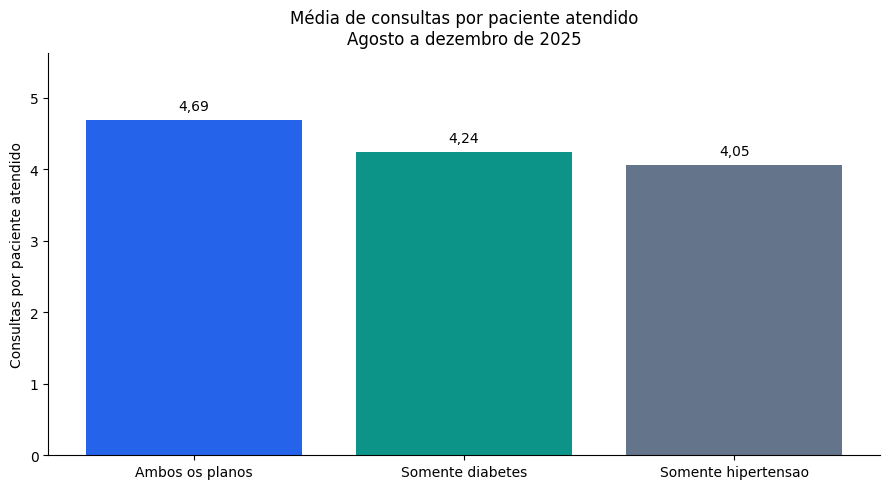

In [0]:
%python
import matplotlib.pyplot as plt

dados = spark.sql("""
    SELECT g.grupo, COUNT(*) * 1.0 / COUNT(DISTINCT f.paciente_id) AS media_consultas FROM workspace.vitacare_mvp.fato_consultas AS f
        INNER JOIN workspace.vitacare_mvp.pacientes_grupos AS g
            ON f.paciente_id = g.paciente_id
    GROUP BY g.grupo
    ORDER BY media_consultas DESC
""").toPandas()

dados["media_consultas"] = dados["media_consultas"].astype(float)

# Criar o gráfico.
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    dados["grupo"],
    dados["media_consultas"],
    color=["#2563EB", "#0D9488", "#64748B"]
)

ax.bar_label(
    barras,
    labels=[f"{valor:.2f}".replace(".", ",")
            for valor in dados["media_consultas"]],
    padding=5
)

ax.set_title("Média de consultas por paciente atendido\nAgosto a dezembro de 2025")
ax.set_ylabel("Consultas por paciente atendido")
ax.set_ylim(0, dados["media_consultas"].max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Resultado da comparação entre os grupos

No período de agosto a dezembro de 2025, os pacientes presentes nos dois planos tiveram a maior média de consultas por paciente atendido (4,69), seguidos pelos pacientes somente no plano de diabetes (4,24) e somente no plano de hipertensão (4,05).

O grupo somente no plano de hipertensão apresentou o maior volume total, com 68.040 registros de consultas e 16.781 pacientes atendidos.

As médias consideram apenas quem teve consulta no período. As consultas podem ter ocorrido por diferentes motivos, não necessariamente por
diabetes ou hipertensão.

## Conclusões

O MVP realizou a carga de arquivos Parquet no Databricks, o tratamento
da data das consultas e a criação de um modelo estrela com três dimensões:
paciente, unidade e data.

O processamento foi organizado em camadas Bronze, Silver e Gold.
Também foi criada uma tabela com o resumo mensal das consultas.

### Principais resultados

- Foram analisados 312.339 registros de consultas, entre agosto e dezembro de 2025.
- Foram identificados 88.992 pacientes atendidos em 27 unidades.
- Outubro apresentou o maior volume, com 74.725 registros de consultas.
- Foram identificados 1.204 pacientes atendidos em mais de uma unidade.
  Esse resultado não comprova encaminhamento entre unidades.
- Nos planos de acompanhamento, foram identificados 3.976 pacientes
  somente no plano de diabetes, 26.362 somente no de hipertensão
  e 10.678 em ambos, considerando as extrações carregadas.

## Qualidade dos dados e limitações

Na base de consultas, não foram encontrados identificadores de consulta
ausentes ou repetidos. As datas convertidas ficaram sem valores ausentes,
e os horários e competências foram conferidos.

Todas as consultas encontraram correspondência nas dimensões de paciente,
unidade e data, sem aumento da quantidade de registros após as ligações.

Foram encontrados 459 registros sem identificação do profissional.
Esses registros foram preservados.

A faixa etária utilizada é a de referência do cadastro e não necessariamente
a idade na data do atendimento. As validações realizadas não comprovam
a exatidão de todas as informações registradas na origem.

O tratamento e a documentação mais completos ficaram concentrados
na base de consultas. Nem todas as colunas das demais fontes foram avaliadas.

## Autoavaliação

Foi possível construir um fluxo na nuvem, desde a carga dos arquivos
até a gravação de tabelas para análise. O trabalho permitiu praticar SQL,
tratamento de datas, verificações de qualidade e modelagem dimensional.

As perguntas foram respondidas parcialmente. As análises por bairro,
perfil dos grupos crônicos, retorno à mesma unidade e profissionais
ficaram para uma próxima versão, assim como a ampliação do catálogo
e das verificações das demais fontes.

O resultado atende ao escopo implementado, mas ainda pode ser ampliado
e melhorado.